In [19]:
import pandas as pd
import re

def corregir_desplazando_coma(valor):
    """
    Corrige la coordenada desplazando la coma decimal para que esté en rango de Asunción
    Asunción: latitud ~ -25.3, longitud ~ -57.6
    """
    if pd.isna(valor) or valor == '':
        return None
    
    valor = str(valor).strip().replace(' ', '')
    
    # Eliminar comas de miles y dejar solo la coma decimal
    valor_sin_comas = valor.replace(',', '')
    
    # Si tiene punto, podría ser decimal correcto
    if '.' in valor_sin_comas:
        try:
            num = float(valor_sin_comas)
            # Si ya está en rango aproximado, mantener
            if -26 < num < -24 or -58 < num < -57:
                return num
        except:
            pass
    
    # Para valores sin punto decimal claro
    # Buscar patrón de números
    numeros = re.findall(r'-?\d+', valor_sin_comas)
    if numeros:
        num_str = ''.join(numeros)
        
        # Determinar si es latitud o longitud por el rango
        if len(num_str) >= 5:
            # Insertar punto decimal después de los primeros 2-3 dígitos
            if num_str.startswith('-'):
                # Negativo
                if len(num_str) > 6:  # Muy largo, probablemente -252... 
                    # Para -252..., debería ser -25.2...
                    num_corregido = float(f"-{num_str[1:3]}.{num_str[3:]}")
                else:
                    num_corregido = float(f"{num_str[:3]}.{num_str[3:]}")
            else:
                # Positivo (longitud podría ser -57...)
                if len(num_str) > 5:
                    num_corregido = float(f"{num_str[:2]}.{num_str[2:]}")
                else:
                    num_corregido = float(f"{num_str[:2]}.{num_str[2:]}")
            
            # Verificar si necesita más corrección
            if abs(num_corregido) > 100:
                num_corregido = num_corregido / 10
            if abs(num_corregido) > 100:
                num_corregido = num_corregido / 10
                
            return round(num_corregido, 6)
    
    return None


# Datos proporcionados
datos = """-25,304311	-57,652086
-25,303704	-57,653457
-25,303265	-57654248
-25,302591	-57,656030
-25,301702	-57,655314
-25,300933	-57,653370
-25,301348	-57,652596
-25,301514	-57,651952
-25,301307	-57,651125
-25,3018	-57.650208
-25,303,110	-57,651,763
-25,303,410	-57,652,502
-25,302,297	-57,653,754
-252,907,772	-576,489,138
-2,529,061,177	-576,488,018
-25,291,868	-57,648,422
-252,911,319	-576,473,856
-252,905,186	-576,467,640
-252,912,883	-576,464,244
-252,920,631	-576,469,545
-252,928,143	-576,472,844
-252,930,028	-576,465,897
-252,939,268	-5,764,456,979
-252,950,271	-576,464,844
-25,294,940	-57,645,142
-252,944,476	-576,448,010
-25,293,786	-57,644,291
-25,296,446	-57,652,968
-25,295,425	-57,652,634
-25,293,236	-57,650,755
-25,294,287	-57,651,134
-25.294618	-57,650,566
-25,293,347	-57,653,570
-25,295,433	-57,652,816
-25,295,971	-57,649,437
-25,295,688	-57,647,817
-25,294,769	-57,645,458
-25,293,637	-57,646,620
-25,294,273	-57,648,239
-25,298,072	-57,646,317
-25,295,902	-57,646,091
-25,301,121	-57,654,221
-253,016,775	-57,654,603
-25,300,714	-57,652,800
-25,299,432	-57,651,941
-25,298,765	-57,651,695
-25,297,757	-57,653,498
-25,296,569	-57,654,325
-25,296,117	-57,652,190
-25,296,615	-57,651,269
-25,298,910	-57,650,042
-25,298,344	-57,649,580
-25,298,475	-57,649,432
-25,298,802	-57,649,203
-25,299,649	-57,646,336
-252884560	-576,473,359
-252,889,853	-576,466,091
-252,879,282	-576,461,931
-252,881,461	-576,464,615
-252,879,052	-576,451,242
-252,894,373	-576,439,135
-252,891,199	-576,431,102
-252,900,105	-576,428,091
-252,911,064	-5,764,636,419
-252,920,755	-576,432,604
-252,905,917	-576,456,482
-252,904,152	-576,441,824
-252,907,075	-576,443,534
-25,300,333	-57,664,479
-253,014,920	-57,664,528
-25,302,199	-57,664,516
-253,023,300	-57,663,669
-25,302,606	-57,665,742
-25,303,440	-57,666,392
-25,305,106	-57,667,066
-25,305,207	-57,666,211
-25,306,056	-57,664,643
-25,306,693	-57,666,636
-25,305,436	-57,667,566
-25,307,902	-57,667,782
-25,308,076	-57,667,647
-25,309,598	-57,663,343
-25,309,879	-57,666,828
-25,309,824	-57,667,327
-25,308,189	-57,665,620
-25,303,449	-57,668,087
-25,304,486	-57,666,945
-25,314,391	-57,668,816
-25,314,862	-57,669,036
-25,314,888	-57,664,421
-25,315,040	-57,668,181
-25,316,204	-57,661,556
-25,316,115	-57,668,227
-25,316,742	-57,667,800
-25,317,108	-57,666,175
-25,316,284	-57,665,270
-25,315,911	-57,664,316
-25,315,3212-57,664,634
-25,314,636	-57,664,643
-25,313,564	-57,665,560
-25,312,855	-57,665,073
-25,312,555	-57,666,777
-25,311,723	-57,668,606
-25,312,083	-57,668,225
-253,115,517	-57,667,294
-25,310,832	-57,666,834"""

# Procesar línea por línea
coordenadas_finales = []

lineas = datos.strip().split('\n')
for linea in lineas:
    if linea.strip():
        partes = linea.strip().split('\t')
        if len(partes) == 2:
            lat_corregida = corregir_desplazando_coma(partes[0])
            lon_corregida = corregir_desplazando_coma(partes[1])
            
            if lat_corregida is not None and lon_corregida is not None:
                coordenadas_finales.append([lat_corregida, lon_corregida])

# Crear DataFrame y guardar CSV
df_final = pd.DataFrame(coordenadas_finales, columns=['latitud', 'longitud'])
df_final.to_csv('coordenadas_finales.csv', 
                index=False, 
                header=False,
                float_format='%.6f')
df_final.sort_values(by=[ 'longitud'], inplace=True)

print(f"Archivo 'coordenadas_finales.csv' generado con {len(df_final)} puntos")
print("\nPrimeras 10 coordenadas:")
print(df_final.head(10).to_string(index=False, header=False))

print(f"\nRango de latitudes: {df_final['latitud'].min():.6f} a {df_final['latitud'].max():.6f}")
print(f"Rango de longitudes: {df_final['longitud'].min():.6f} a {df_final['longitud'].max():.6f}")

Archivo 'coordenadas_finales.csv' generado con 105 puntos

Primeras 10 coordenadas:
-25.314862 -57.669036
-25.314391 -57.668816
-25.311723 -57.668606
-25.316115 -57.668227
-25.312083 -57.668225
-25.315040 -57.668181
-25.303449 -57.668087
-25.316742 -57.667800
-25.307902 -57.667782
-25.308076 -57.667647

Rango de latitudes: -25.317108 a -25.287905
Rango de longitudes: -57.669036 a -57.642809


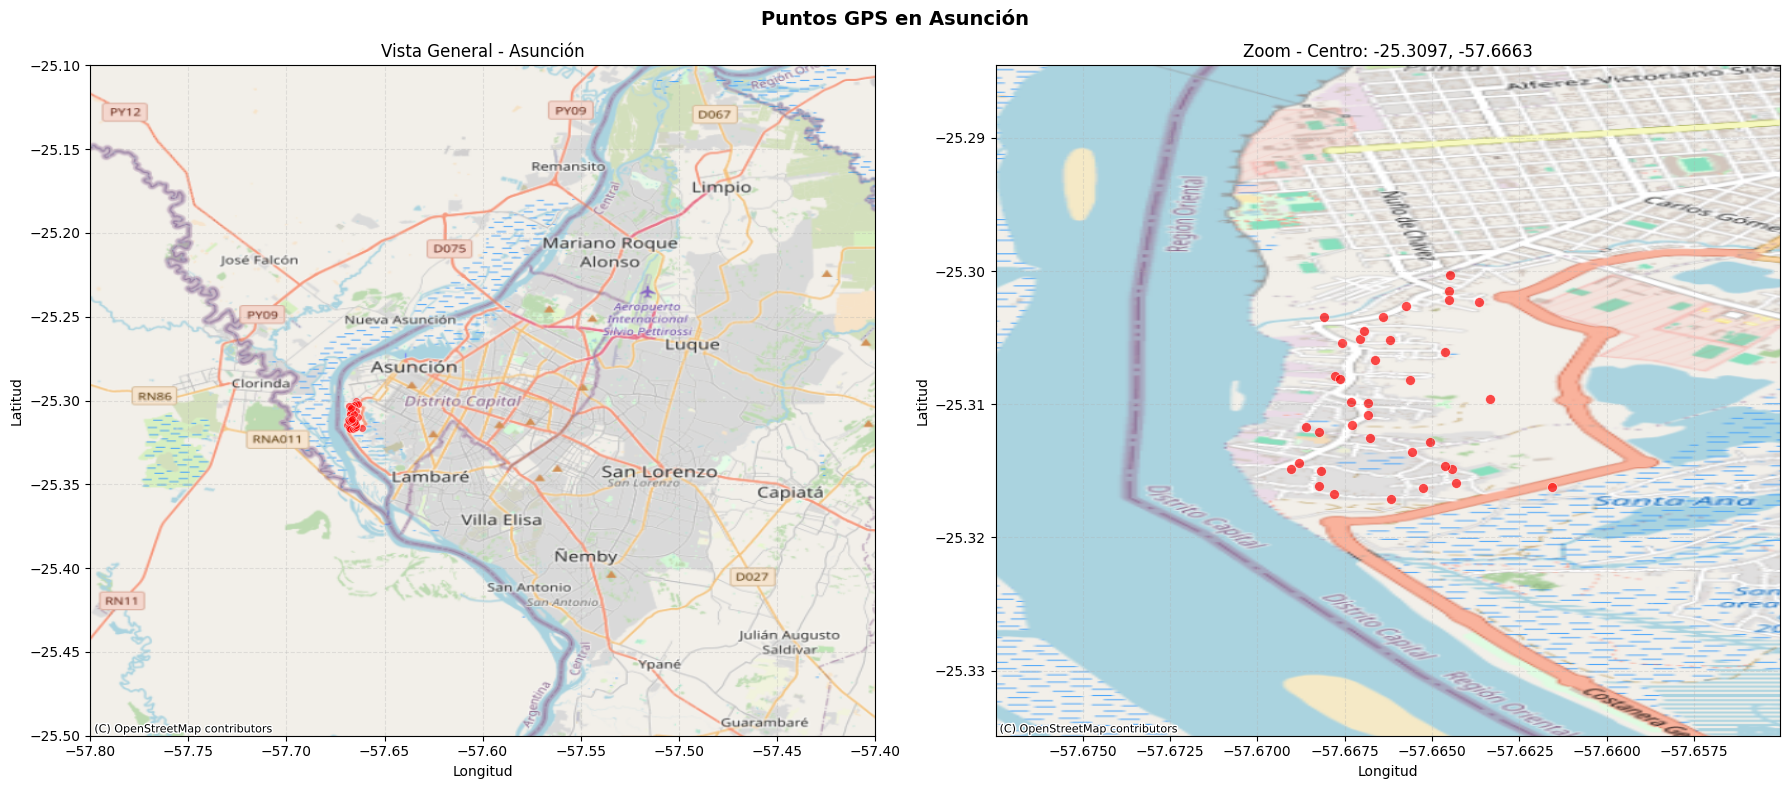

In [23]:
def plot_mapa_asuncion_doble(df, titulo="Puntos GPS en Asunción"):
    """
    Crea dos mapas: vista general y zoom
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    
    # Mapa 1: Vista general de Asunción
    ax1.scatter(df['longitud'], df['latitud'], 
               c='red', s=30, alpha=0.6, edgecolors='white', linewidth=0.5)
    ax1.set_xlim(-57.8, -57.4)
    ax1.set_ylim(-25.5, -25.1)
    ctx.add_basemap(ax1, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik)
    ax1.set_title('Vista General - Asunción', fontsize=12)
    ax1.set_xlabel('Longitud')
    ax1.set_ylabel('Latitud')
    ax1.grid(True, alpha=0.3, linestyle='--')
    
    # Mapa 2: Zoom al centro de los puntos
    lon_center = df['longitud'].mean()
    lat_center = df['latitud'].mean()
    lon_range = df['longitud'].max() - df['longitud'].min()
    lat_range = df['latitud'].max() - df['latitud'].min()
    
    zoom_factor = 1.5
    ax2.scatter(df['longitud'], df['latitud'], 
               c='red', s=50, alpha=0.7, edgecolors='white', linewidth=0.5)
    ax2.set_xlim(lon_center - lon_range * zoom_factor, lon_center + lon_range * zoom_factor)
    ax2.set_ylim(lat_center - lat_range * zoom_factor, lat_center + lat_range * zoom_factor)
    ctx.add_basemap(ax2, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik)
    ax2.set_title(f'Zoom - Centro: {lat_center:.4f}, {lon_center:.4f}', fontsize=12)
    ax2.set_xlabel('Longitud')
    ax2.set_ylabel('Latitud')
    ax2.grid(True, alpha=0.3, linestyle='--')
    
    plt.suptitle(titulo, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return fig, (ax1, ax2)

# Leer datos y graficar versión doble
df = pd.read_csv('tacumbu1.csv', header=None, names=['latitud', 'longitud'])
fig, axes = plot_mapa_asuncion_doble(df)
#fig.savefig('mapa_asuncion_doble.png', dpi=300, bbox_inches='tight')

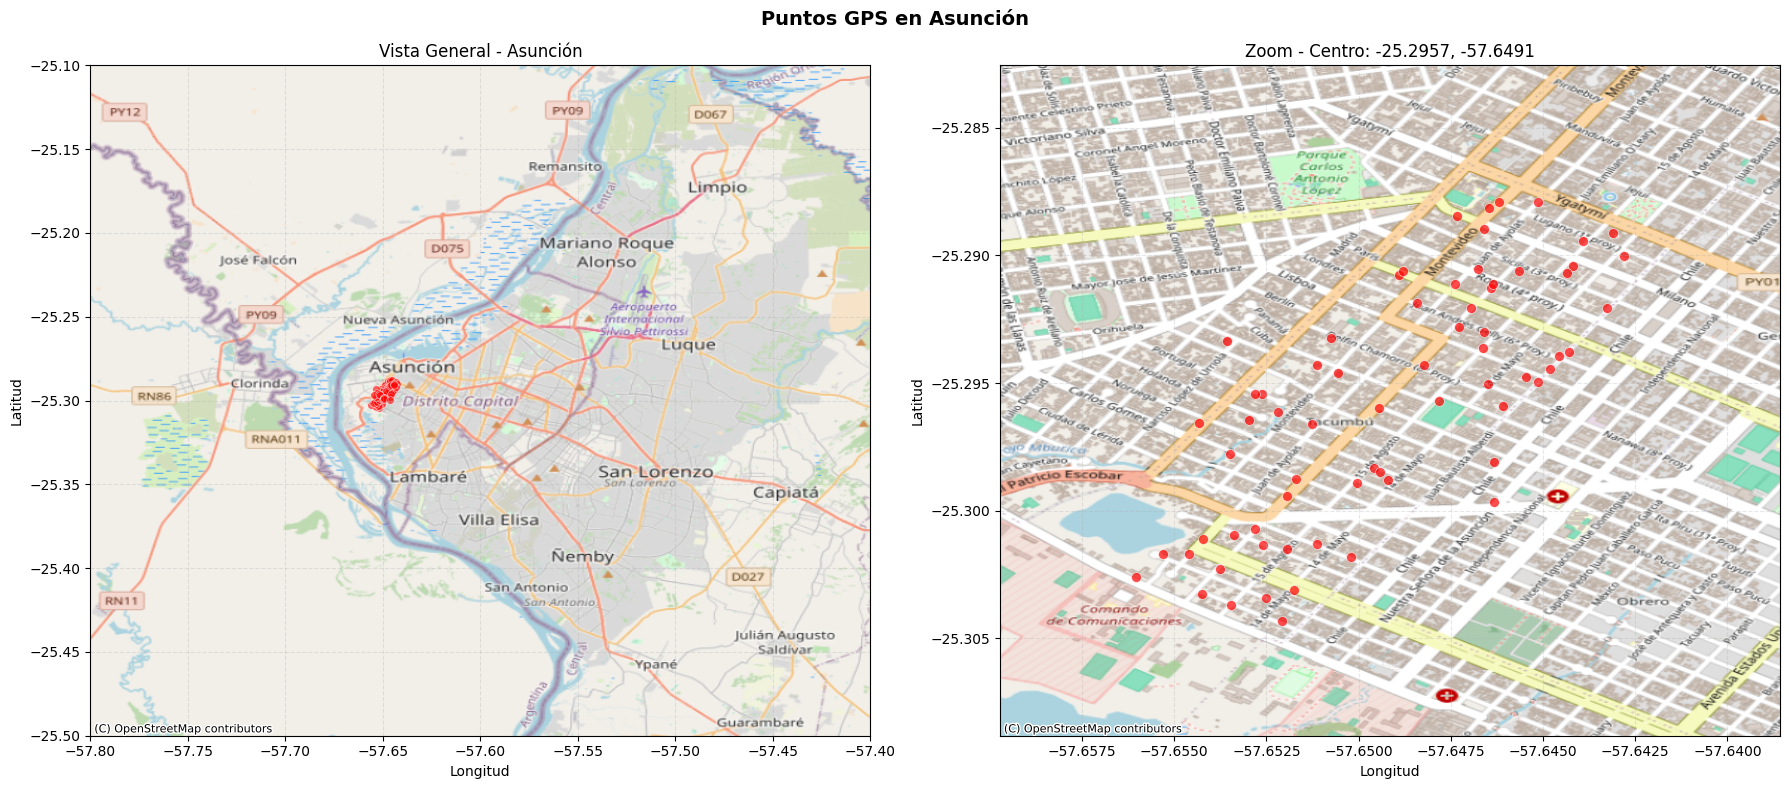

In [21]:
df = pd.read_csv('tacumbu2.csv', header=None, names=['latitud', 'longitud'])
fig, axes = plot_mapa_asuncion_doble(df)
#fig.savefig('mapa_asuncion_doble.png', dpi=300, bbox_inches='tight')